## IMT574 - Midterm Notebook
Miranda Rasmussen <br>
10/19/2025<br>
IMT 574: Data Science II: Machine Learning<br>
Instructor: Sophin Liu


### **PART 1**
#### INSTRUCTIONS
This database contains 34 attributes. 35th is the class label, i.e. the disease name. The names and id numbers of the patients were removed from the database.

The differential diagnosis of erythemato-squamous diseases is a real problem in dermatology. They all share the clinical features of erythema and scaling, with very little differences. The diseases in this group are psoriasis, seboreic dermatitis, lichen planus, pityriasis rosea, cronic dermatitis, and pityriasis rubra pilaris. Usually a biopsy is necessary for the diagnosis but unfortunately these diseases share many histopathological features as well. Another difficulty for the differential diagnosis is that a disease may show the features of another disease at the beginning stage and may have the characteristic features at the following stages. Patients were first evaluated clinically with 12 features. Afterwards, skin samples were taken for the evaluation of 22 histopathological features. The values of the histopathological features are determined by an analysis of the samples under a microscope.

In the dataset constructed for this domain, the family history feature has the value 1 if any of these diseases has been observed in the family, and 0 otherwise. The age feature simply represents the age of the patient. Every other feature (clinical and histopathological) was given a degree in the range of 0 to 3. Here, 0 indicates that the feature was not present, 3 indicates the largest amount possible, and 1, 2 indicate the relative intermediate values.

Assuming that the list of diseases in this group are complete (total 6 types), use the dataset to address the following list of objectives:

a. Let’s try determining the type of disease based on the patient’s Age. Use gradient ascent to build your model (model1). Start by writing the gradient ascent  algorithm and then implement it using a programming language of your choice.

b. Use random forest on the clinical as well as histopathological attributes to classify the disease type (model2). 

c. Use kNN on the clinical attributes and histopathological attributes to classify the disease type and report your accuracy (model3). 

d. Finally, use two different clustering algorithms and see how well these attributes can determine the disease type (model4 and model5). 

Make sure to report your actual model for each of the above. This means providing appropriate details containing the features used, parameters learned/estimated, and any inputs (e.g., number of clusters, error limit) that go into the technique. When appropriate, perform multiple runs of the same technique and report average values or their spread.

e. Now, compare and contrast the five models you built. Having done both classification and clustering on the same dataset, what can you say about this data and/or the techniques you used? Write your thoughts in 2-3 paragraphs. 

### Preparation

In [1]:
#import packages needed
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.cluster.hierarchy import linkage, dendrogram

pd.set_option('display.max_columns', 100)


# Part 1 Dermatology (Classification)
**Objective:** build classification models to predict the diagnostic class and compare performance.

### 1.0. Load and review the dataset

In [2]:
#Load
derm_path = "dermatology.csv"
derm = pd.read_csv(derm_path)
print('Shape:', derm.shape)
derm.head()

Shape: (366, 1)


,Erythema\tScathing\tDefinite Borders\tItching\tKoebner \tPolygonal\tFollicular\tOral\tKnee\tScalp\tFamily Hostory\tMelanin\tEosinophils\tPNL\tFibrosis\tExocytosis\tAcanothosis\tHyperkeratosis\tParakeratosis\tClubbing\tElongation\tThinning\tSpongiform\tMunro\tFocal\tDisapperance\tVacuolisation\tSpongiosis\tRetes\tFollicular\tPerifollicular\tInflamatory\tBand-like\tAge\tDisease
0,2\t2\t0\t3\t0\t0\t0\t0\t1\t0\t0\t0\t0\t0\t0\t3...
1,3\t3\t3\t2\t1\t0\t0\t0\t1\t1\t1\t0\t0\t1\t0\t1...
2,2\t1\t2\t3\t1\t3\t0\t3\t0\t0\t0\t1\t0\t0\t0\t1...
3,2\t2\t2\t0\t0\t0\t0\t0\t3\t2\t0\t0\t0\t3\t0\t0...
4,2\t3\t2\t2\t2\t2\t0\t2\t0\t0\t0\t1\t0\t0\t0\t1...


### 1.0. Separate tab delimited data

In [3]:
derm = pd.read_csv(derm_path, sep="\t")

print("Shape after tab separation:", derm.shape)
print("Columns detected:", derm.columns.tolist())
derm.head()

Shape after tab separation: (366, 35)
Columns detected: ['Erythema', 'Scathing', 'Definite Borders', 'Itching', 'Koebner ', 'Polygonal', 'Follicular', 'Oral', 'Knee', 'Scalp', 'Family Hostory', 'Melanin', 'Eosinophils', 'PNL', 'Fibrosis', 'Exocytosis', 'Acanothosis', 'Hyperkeratosis', 'Parakeratosis', 'Clubbing', 'Elongation', 'Thinning', 'Spongiform', 'Munro', 'Focal', 'Disapperance', 'Vacuolisation', 'Spongiosis', 'Retes', 'Follicular.1', 'Perifollicular', 'Inflamatory', 'Band-like', 'Age', 'Disease']


,Erythema,Scathing,Definite Borders,Itching,Koebner,Polygonal,Follicular,Oral,Knee,Scalp,Family Hostory,Melanin,Eosinophils,PNL,Fibrosis,Exocytosis,Acanothosis,Hyperkeratosis,Parakeratosis,Clubbing,Elongation,Thinning,Spongiform,Munro,Focal,Disapperance,Vacuolisation,Spongiosis,Retes,Follicular.1,Perifollicular,Inflamatory,Band-like,Age,Disease
0,2,2,0,3,0,0,0,0,1,0,0,0,0,0,0,3,2,0,0,0,0,0,0,0,0,0,0,3,0,0,0,1,0,55,2
1,3,3,3,2,1,0,0,0,1,1,1,0,0,1,0,1,2,0,2,2,2,2,2,1,0,0,0,0,0,0,0,1,0,8,1
2,2,1,2,3,1,3,0,3,0,0,0,1,0,0,0,1,2,0,2,0,0,0,0,0,2,0,2,3,2,0,0,2,3,26,3
3,2,2,2,0,0,0,0,0,3,2,0,0,0,3,0,0,2,0,3,2,2,2,2,0,0,3,0,0,0,0,0,3,0,40,1
4,2,3,2,2,2,2,0,2,0,0,0,1,0,0,0,1,2,0,0,0,0,0,0,0,2,2,3,2,3,0,0,2,3,45,3


### 1.A Gradient Ascent Logistic Regression

In [4]:
#Standardize headers and drop empty columns
derm.columns = derm.columns.str.strip()
derm = derm.dropna(axis=1, how="all")

#Identify class/target column
target_col = "class" if "class" in derm.columns else derm.columns[-1]

#Coerce numerics and handle '?' as NaN if present
derm = derm.replace("?", np.nan)
for c in derm.columns:
    try:
        derm[c] = pd.to_numeric(derm[c])
    except Exception:
        pass

#Select rows with non-missing Age and Class
if "Age" not in derm.columns:
    print("Could not find 'Age' column. Available columns:", derm.columns.tolist())
else:
    derm = derm[~derm["Age"].isna() & ~derm[target_col].isna()].copy()

print("Shape after cleaning:", derm.shape)
print("Target column:", target_col)
derm[["Age", target_col]].head()

Shape after cleaning: (358, 35)
Target column: Disease


,Age,Disease
0,55.0,2
1,8.0,1
2,26.0,3
3,40.0,1
4,45.0,3


In [5]:
#Extract Freatures and Target
X_age = derm[["Age"]].values  # shape (n, 1)
y_raw = derm[target_col].values

#Map class labels to 0..K-1
classes, y = np.unique(y_raw, return_inverse=True) 
K = len(classes)

#Standardize Age to help optimization
scaler = StandardScaler()
Z = scaler.fit_transform(X_age)

#Design matrix Xb = [1, z]
ones = np.ones((Z.shape[0], 1))
Xb = np.hstack([ones, Z]) 

# Train/test split
Xb_train, Xb_test, y_train, y_test = train_test_split(Xb, y, test_size=0.25, random_state=42, stratify=y)

print("Train size:", Xb_train.shape, "  Test size:", Xb_test.shape)
print("Number of classes (K):", K)

Train size: (268, 2)   Test size: (90, 2)
Number of classes (K): 6


In [6]:
#Softmax, one-hot, and log-likelihood
def softmax(logits):
    # logits: (n, K)
    m = np.max(logits, axis=1, keepdims=True)
    exps = np.exp(logits - m)
    probs = exps / np.sum(exps, axis=1, keepdims=True)
    return probs

def one_hot(y, K):
    Y = np.zeros((y.shape[0], K))
    Y[np.arange(y.shape[0]), y] = 1.0
    return Y

def avg_log_likelihood(Xb, y, W, reg_lambda=0.0):
    # Xb: (n, 2); W: (K, 2); y: (n,)
    logits = Xb.dot(W.T)  # (n, K)
    P = softmax(logits)
    n = Xb.shape[0]
    ll = 0.0
    for i in range(n):
        ll += np.log(P[i, y[i]] + 1e-12)  # avoid log(0)
    ll = ll / n
    if reg_lambda > 0.0:
        ll = ll - 0.5 * reg_lambda * np.sum(W * W)
    return ll

#Train model 1 with gradient ascent
rng = np.random.RandomState(42)

K = len(classes)
d = Xb_train.shape[1] 
W = rng.normal(loc=0.0, scale=0.01, size=(K, d))  

eta = 0.1            #learning rate
epochs = 2000        #iterations
reg_lambda = 0.001   #small L2 penalty for stability

Y_train_oh = one_hot(y_train, K)
n = Xb_train.shape[0]

history = []
for t in range(epochs):
    # Forward
    logits = Xb_train.dot(W.T)        # (n, K)
    P = softmax(logits)               # (n, K)

    #Gradient of average log-likelihood
    diff = Y_train_oh - P             # (n, K)
    grad = diff.T.dot(Xb_train) / float(n) - reg_lambda * W

    #Ascent
    W = W + eta * grad

    if (t+1) % 200 == 0 or t == 0:
        ll = avg_log_likelihood(Xb_train, y_train, W, reg_lambda=reg_lambda)
        history.append(ll)
        print("Iter", t+1, " Avg Log-Likelihood:", ll)

print("Training complete. Final avg log-likelihood:", avg_log_likelihood(Xb_train, y_train, W, reg_lambda=reg_lambda))

Iter 1  Avg Log-Likelihood: -1.7857202522316613
Iter 200  Avg Log-Likelihood: -1.6007844023286593
Iter 400  Avg Log-Likelihood: -1.579173527525253
Iter 600  Avg Log-Likelihood: -1.5688761286018007
Iter 800  Avg Log-Likelihood: -1.5627328461990846
Iter 1000  Avg Log-Likelihood: -1.558653717596247
Iter 1200  Avg Log-Likelihood: -1.5557683582877062
Iter 1400  Avg Log-Likelihood: -1.5536402544581667
Iter 1600  Avg Log-Likelihood: -1.5520233594771404
Iter 1800  Avg Log-Likelihood: -1.5507673492320675
Iter 2000  Avg Log-Likelihood: -1.5497748045092679
Training complete. Final avg log-likelihood: -1.5497748045092679


In [7]:
#Evaluate model1 on train/test
def predict_classes(Xb, W):
    logits = Xb.dot(W.T)
    P = softmax(logits)
    yhat = np.argmax(P, axis=1)
    return yhat

yhat_train = predict_classes(Xb_train, W)
yhat_test  = predict_classes(Xb_test,  W)

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

acc_tr = accuracy_score(y_train, yhat_train)
acc_te = accuracy_score(y_test, yhat_test)
print("Train accuracy:", acc_tr)
print("Test  accuracy:", acc_te)

print("\nConfusion matrix (test):")
print(confusion_matrix(y_test, yhat_test))

print("\nClassification report (test):")
print(classification_report(y_test, yhat_test, target_names=[str(c) for c in classes]))

Train accuracy: 0.35074626865671643
Test  accuracy: 0.34444444444444444

Confusion matrix (test):
[[26  0  0  0  0  2]
 [13  0  0  0  0  2]
 [18  0  0  0  0  0]
 [12  0  0  0  0  0]
 [11  0  0  0  0  1]
 [ 0  0  0  0  0  5]]

Classification report (test):
              precision    recall  f1-score   support

           1       0.33      0.93      0.48        28
           2       0.00      0.00      0.00        15
           3       0.00      0.00      0.00        18
           4       0.00      0.00      0.00        12
           5       0.00      0.00      0.00        12
           6       0.50      1.00      0.67         5

    accuracy                           0.34        90
   macro avg       0.14      0.32      0.19        90
weighted avg       0.13      0.34      0.19        90



/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


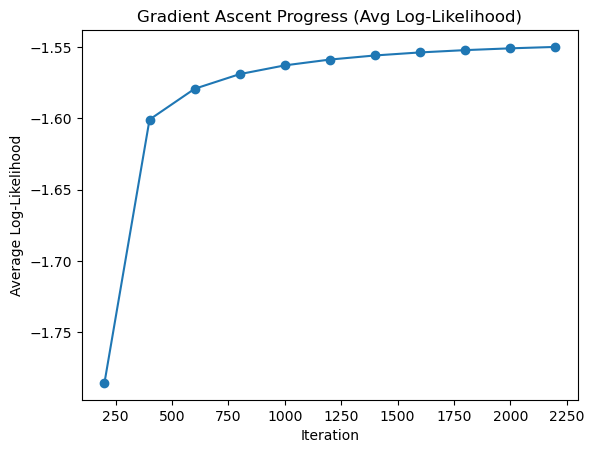

In [8]:
if 'history' in globals() and len(history) > 0:
    plt.figure()
    plt.plot(np.arange(1, len(history) + 1) * 200, history, marker='o')  # we logged every 200 iters
    plt.title("Gradient Ascent Progress (Avg Log-Likelihood)")
    plt.xlabel("Iteration")
    plt.ylabel("Average Log-Likelihood")
    plt.show()
else:
    print("NO 'history' FOUND.")

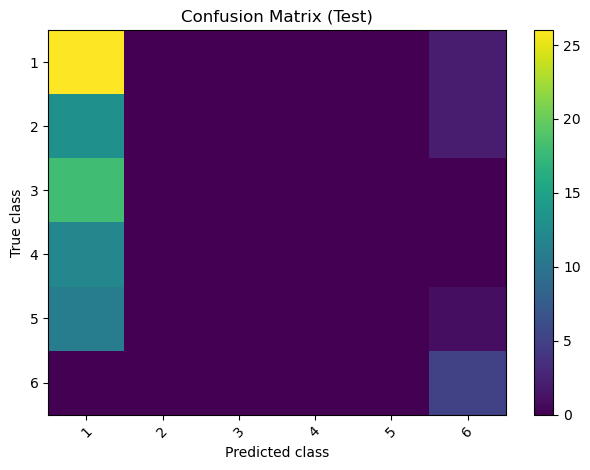

Confusion matrix:
 [[26  0  0  0  0  2]
 [13  0  0  0  0  2]
 [18  0  0  0  0  0]
 [12  0  0  0  0  0]
 [11  0  0  0  0  1]
 [ 0  0  0  0  0  5]]


In [9]:
cm = confusion_matrix(y_test, yhat_test)
plt.figure()
plt.imshow(cm, aspect='auto')
plt.title("Confusion Matrix (Test)")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.colorbar()
plt.xticks(np.arange(len(classes)), [str(c) for c in classes], rotation=45)
plt.yticks(np.arange(len(classes)), [str(c) for c in classes])
plt.tight_layout()
plt.show()

print("Confusion matrix:\n", cm)

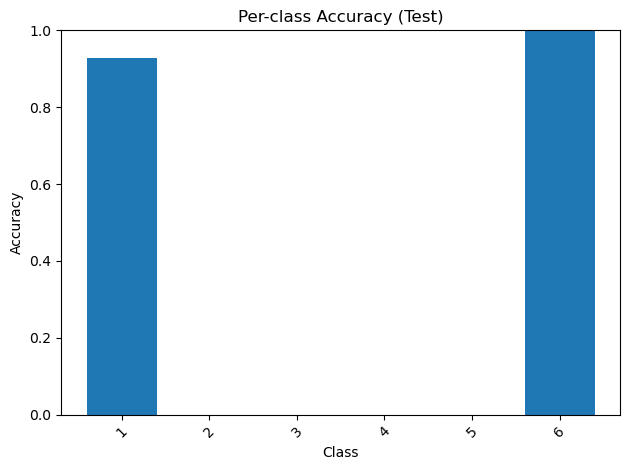

Per-class accuracy: [0.92857143 0.         0.         0.         0.         1.        ]


In [10]:
supports = np.bincount(y_test, minlength=len(classes))
corrects = np.bincount(y_test[y_test == yhat_test], minlength=len(classes))
per_class_acc = np.zeros(len(classes))
for i in range(len(classes)):
    if supports[i] > 0:
        per_class_acc[i] = corrects[i] / float(supports[i])

plt.figure()
plt.bar(np.arange(len(classes)), per_class_acc)
plt.title("Per-class Accuracy (Test)")
plt.xlabel("Class")
plt.ylabel("Accuracy")
plt.xticks(np.arange(len(classes)), [str(c) for c in classes], rotation=45)
plt.ylim(0.0, 1.0)
plt.tight_layout()
plt.show()

print("Per-class accuracy:", per_class_acc)

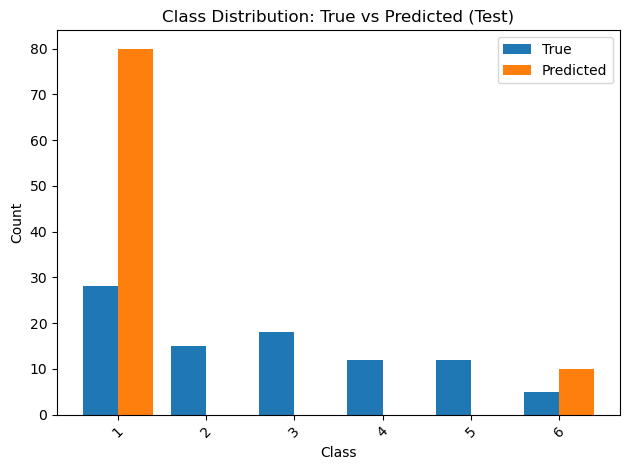

True counts: [28 15 18 12 12  5]
Predicted counts: [80  0  0  0  0 10]


In [11]:
true_counts = np.bincount(y_test, minlength=len(classes))
pred_counts = np.bincount(yhat_test, minlength=len(classes))

idx = np.arange(len(classes))
width = 0.4

plt.figure()
plt.bar(idx - width/2.0, true_counts, width)
plt.bar(idx + width/2.0, pred_counts, width)
plt.title("Class Distribution: True vs Predicted (Test)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(idx, [str(c) for c in classes], rotation=45)
plt.legend(["True", "Predicted"])
plt.tight_layout()
plt.show()

print("True counts:", true_counts)
print("Predicted counts:", pred_counts)

### 1.B. Random Forest on Clinical and Histopathological Attributes

In [12]:
#Features: clinical + histopathological attributes
feature_cols = [c for c in derm.columns if c != target_col]
if "Age" in feature_cols:
    feature_cols.remove("Age")  # keep Age out since Model 1 used age-only

X = derm[feature_cols].copy()
y = derm[target_col].copy()

#Remove rows with missing target
mask = ~y.isna()
X = X.loc[mask]
y = y.loc[mask]

print("Rows, cols after cleaning:", X.shape)
print("Target:", target_col)
print("Example feature columns:", feature_cols[:10])

Rows, cols after cleaning: (358, 33)
Target: Disease
Example feature columns: ['Erythema', 'Scathing', 'Definite Borders', 'Itching', 'Koebner', 'Polygonal', 'Follicular', 'Oral', 'Knee', 'Scalp']


In [13]:
#Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

#median-impute missing values
num_proc = Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))])
pre = ColumnTransformer(transformers=[("num", num_proc, feature_cols)])

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

model2 = Pipeline(steps=[("pre", pre), ("rf", rf)])
model2.fit(X_train, y_train)

#Evaluate
y_pred = model2.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("Test accuracy:", acc)
print("\nClassification report:\n", classification_report(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

Test accuracy: 0.9777777777777777

Classification report:
               precision    recall  f1-score   support

           1       0.97      1.00      0.98        28
           2       0.94      1.00      0.97        15
           3       1.00      1.00      1.00        18
           4       1.00      0.92      0.96        12
           5       1.00      1.00      1.00        12
           6       1.00      0.80      0.89         5

    accuracy                           0.98        90
   macro avg       0.98      0.95      0.97        90
weighted avg       0.98      0.98      0.98        90

Confusion matrix:
 [[28  0  0  0  0  0]
 [ 0 15  0  0  0  0]
 [ 0  0 18  0  0  0]
 [ 0  1  0 11  0  0]
 [ 0  0  0  0 12  0]
 [ 1  0  0  0  0  4]]


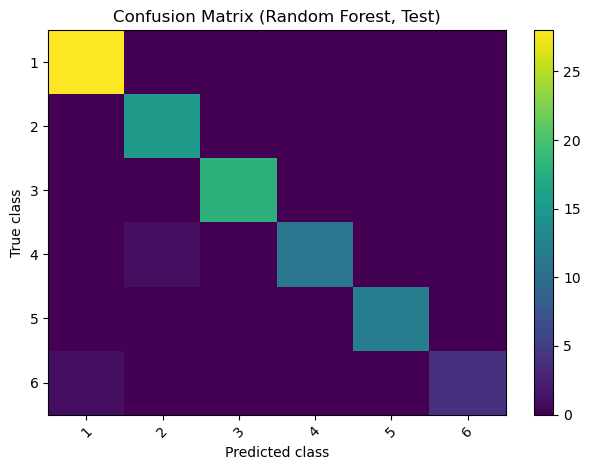

In [14]:
#Confusion Matrix accuracy visual
cm = confusion_matrix(y_test, y_pred)
classes = np.unique(y)  

plt.figure()
plt.imshow(cm, aspect="auto")
plt.title("Confusion Matrix (Random Forest, Test)")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.colorbar()
plt.xticks(np.arange(len(classes)), [str(c) for c in classes], rotation=45)
plt.yticks(np.arange(len(classes)), [str(c) for c in classes])
plt.tight_layout()
plt.show()

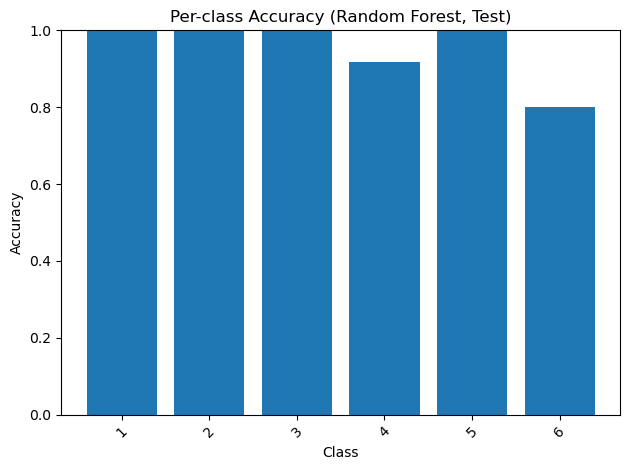

Per-class accuracy: [1.         1.         1.         0.91666667 1.         0.8       ]


In [15]:
#Bar Chart of accuracy
supports = np.bincount(pd.Categorical(y_test, categories=classes).codes, minlength=len(classes))
corrects = np.bincount(
    pd.Categorical(y_test[y_test.values == y_pred], categories=classes).codes,
    minlength=len(classes)
)
per_class_acc = np.zeros(len(classes))
for i in range(len(classes)):
    if supports[i] > 0:
        per_class_acc[i] = corrects[i] / float(supports[i])

plt.figure()
plt.bar(np.arange(len(classes)), per_class_acc)
plt.title("Per-class Accuracy (Random Forest, Test)")
plt.xlabel("Class")
plt.ylabel("Accuracy")
plt.xticks(np.arange(len(classes)), [str(c) for c in classes], rotation=45)
plt.ylim(0.0, 1.0)
plt.tight_layout()
plt.show()

print("Per-class accuracy:", per_class_acc)

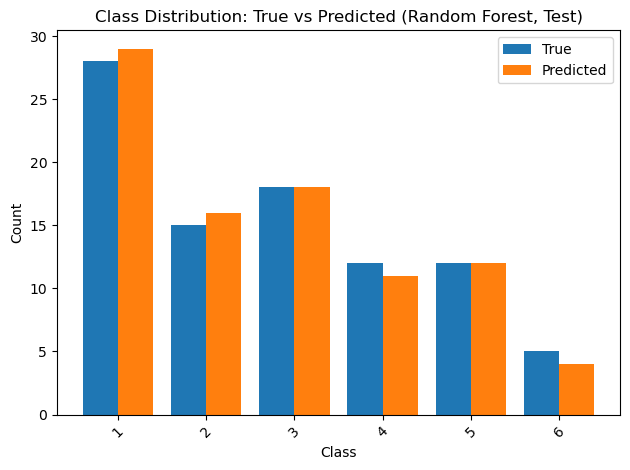

True counts: [28 15 18 12 12  5]
Predicted counts: [29 16 18 11 12  4]


In [16]:
#Bar chart of true vs predicted
true_counts = pd.Series(y_test).value_counts().reindex(classes, fill_value=0).values
pred_counts = pd.Series(y_pred).value_counts().reindex(classes, fill_value=0).values

idx = np.arange(len(classes))
width = 0.4

plt.figure()
plt.bar(idx - width/2.0, true_counts, width, label="True")
plt.bar(idx + width/2.0, pred_counts, width, label="Predicted")
plt.title("Class Distribution: True vs Predicted (Random Forest, Test)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(idx, [str(c) for c in classes], rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

print("True counts:", true_counts)
print("Predicted counts:", pred_counts)

### 1.C. KNN Classification

In [17]:
#check target and features
X = derm[feature_cols].copy()
y = derm[target_col].copy()
mask = ~y.isna()
X = X.loc[mask]
y = y.loc[mask]

print("Rows, columns:", X.shape)
print("Target:", target_col)
print("Feature:", feature_cols)

Rows, columns: (358, 33)
Target: Disease
Feature: ['Erythema', 'Scathing', 'Definite Borders', 'Itching', 'Koebner', 'Polygonal', 'Follicular', 'Oral', 'Knee', 'Scalp', 'Family Hostory', 'Melanin', 'Eosinophils', 'PNL', 'Fibrosis', 'Exocytosis', 'Acanothosis', 'Hyperkeratosis', 'Parakeratosis', 'Clubbing', 'Elongation', 'Thinning', 'Spongiform', 'Munro', 'Focal', 'Disapperance', 'Vacuolisation', 'Spongiosis', 'Retes', 'Follicular.1', 'Perifollicular', 'Inflamatory', 'Band-like']


In [18]:
#Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

num_proc = Pipeline(steps=[("imputer", SimpleImputer(strategy="median")),
                           ("scaler", StandardScaler())])
pre = ColumnTransformer(transformers=[("num", num_proc, feature_cols)])

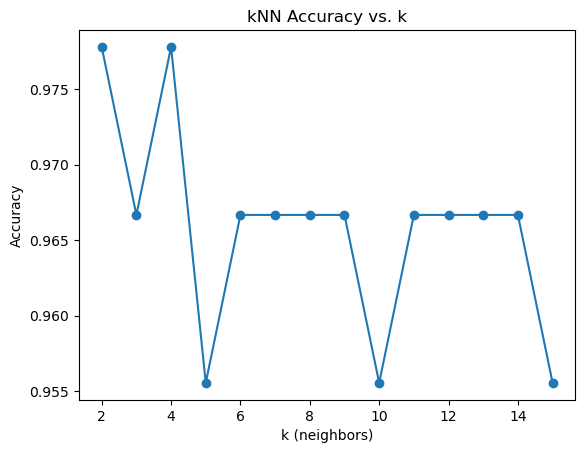

Best k: 2 with accuracy: 0.9777777777777777


In [19]:
#Find K
k_values = list(range(2, 16))
accs = []

for k in k_values:
    knn = Pipeline(steps=[("pre", pre),
                          ("clf", KNeighborsClassifier(n_neighbors=k))])
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accs.append(accuracy_score(y_test, y_pred))

import matplotlib.pyplot as plt

plt.figure()
plt.plot(k_values, accs, marker="o")
plt.title("kNN Accuracy vs. k")
plt.xlabel("k (neighbors)")
plt.ylabel("Accuracy")
plt.show()

best_k = k_values[int(np.argmax(accs))]
print("Best k:", best_k, "with accuracy:", max(accs))

In [20]:
#fit and evaluate
knn_best = Pipeline(steps=[("pre", pre),
                           ("clf", KNeighborsClassifier(n_neighbors=best_k))])
knn_best.fit(X_train, y_train)
y_pred = knn_best.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print("Test accuracy:", acc)
print("\nClassification report:\n", classification_report(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

Test accuracy: 0.9777777777777777

Classification report:
               precision    recall  f1-score   support

           1       1.00      1.00      1.00        28
           2       0.93      0.93      0.93        15
           3       1.00      1.00      1.00        18
           4       0.92      0.92      0.92        12
           5       1.00      1.00      1.00        12
           6       1.00      1.00      1.00         5

    accuracy                           0.98        90
   macro avg       0.97      0.97      0.97        90
weighted avg       0.98      0.98      0.98        90

Confusion matrix:
 [[28  0  0  0  0  0]
 [ 0 14  0  1  0  0]
 [ 0  0 18  0  0  0]
 [ 0  1  0 11  0  0]
 [ 0  0  0  0 12  0]
 [ 0  0  0  0  0  5]]


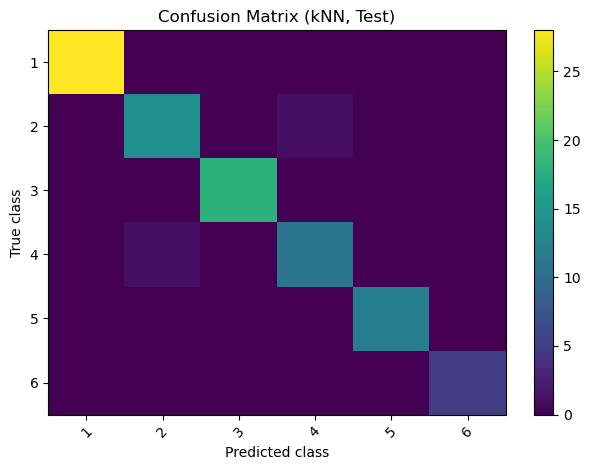

In [21]:
#confusion matrix
cm = confusion_matrix(y_test, y_pred)
classes = np.unique(y)

plt.figure()
plt.imshow(cm, aspect="auto")
plt.title("Confusion Matrix (kNN, Test)")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.colorbar()
plt.xticks(np.arange(len(classes)), [str(c) for c in classes], rotation=45)
plt.yticks(np.arange(len(classes)), [str(c) for c in classes])
plt.tight_layout()
plt.show()

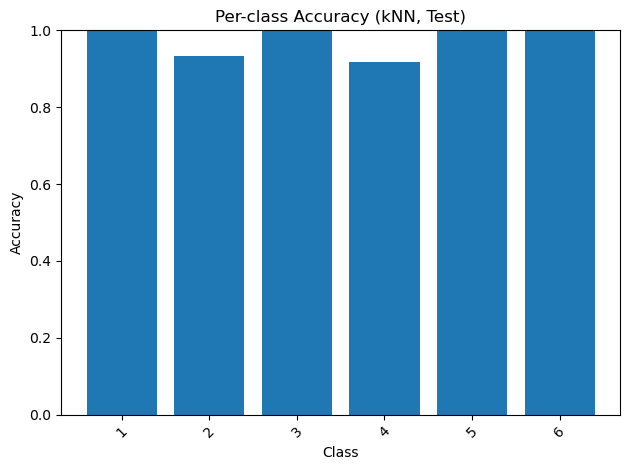

Per-class accuracy: [1.         0.93333333 1.         0.91666667 1.         1.        ]


In [22]:
#Per class accuracy visual
supports = np.bincount(pd.Categorical(y_test, categories=classes).codes,
                       minlength=len(classes))
corrects = np.bincount(
    pd.Categorical(y_test[y_test.values == y_pred], categories=classes).codes,
    minlength=len(classes)
)
per_class_acc = np.zeros(len(classes))
for i in range(len(classes)):
    if supports[i] > 0:
        per_class_acc[i] = corrects[i] / float(supports[i])

plt.figure()
plt.bar(np.arange(len(classes)), per_class_acc)
plt.title("Per-class Accuracy (kNN, Test)")
plt.xlabel("Class")
plt.ylabel("Accuracy")
plt.xticks(np.arange(len(classes)), [str(c) for c in classes], rotation=45)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

print("Per-class accuracy:", per_class_acc)

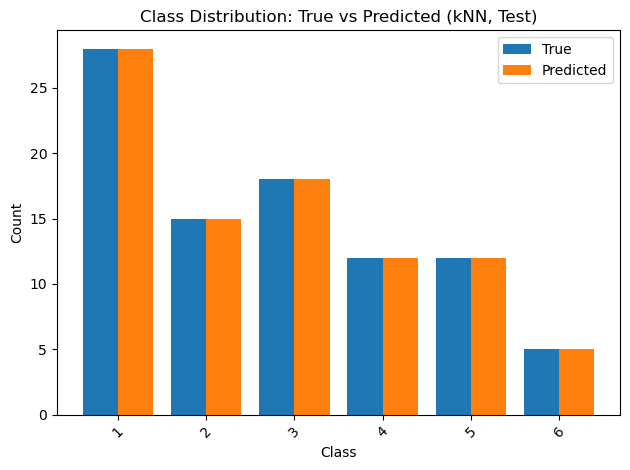

In [23]:
true_counts = pd.Series(y_test).value_counts().reindex(classes, fill_value=0).values
pred_counts = pd.Series(y_pred).value_counts().reindex(classes, fill_value=0).values

idx = np.arange(len(classes))
width = 0.4

plt.figure()
plt.bar(idx - width/2.0, true_counts, width, label="True")
plt.bar(idx + width/2.0, pred_counts, width, label="Predicted")
plt.title("Class Distribution: True vs Predicted (kNN, Test)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(idx, [str(c) for c in classes], rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


### 1.D. Model 4 and 5 Clustering

In [24]:
#Check target and features are still correct
X = derm[feature_cols].copy()
y = derm[target_col].copy()
mask = ~y.isna()
X = X.loc[mask]
y = y.loc[mask]

print("Rows, columns:", X.shape)
print("Target:", target_col)

Rows, columns: (358, 33)
Target: Disease


In [25]:
pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

X_scaled = pipe.fit_transform(X)
print("Scaled data shape:", X_scaled.shape)

Scaled data shape: (358, 33)


In [26]:
#K means clustering
K = len(np.unique(y))
print("Number of clusters:", K)

#Run multiple times to average results
runs = 5
scores = []
ari_scores = []

for r in range(runs):
    km = KMeans(n_clusters=K, random_state=42 + r, n_init=10)
    labels_km = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels_km)
    ari = adjusted_rand_score(y, labels_km)
    scores.append(sil)
    ari_scores.append(ari)
    print(f"Run {r+1}: silhouette={sil:.3f}, ARI={ari:.3f}")

print("\nAverage silhouette:", np.mean(scores), "+/-", np.std(scores))
print("Average ARI:", np.mean(ari_scores), "+/-", np.std(ari_scores))

Number of clusters: 6
Run 1: silhouette=0.235, ARI=0.699
Run 2: silhouette=0.237, ARI=0.722
Run 3: silhouette=0.237, ARI=0.709
Run 4: silhouette=0.236, ARI=0.716
Run 5: silhouette=0.234, ARI=0.707

Average silhouette: 0.23582056464623086 +/- 0.0012449259205547384
Average ARI: 0.7107451555604535 +/- 0.007752668132425097


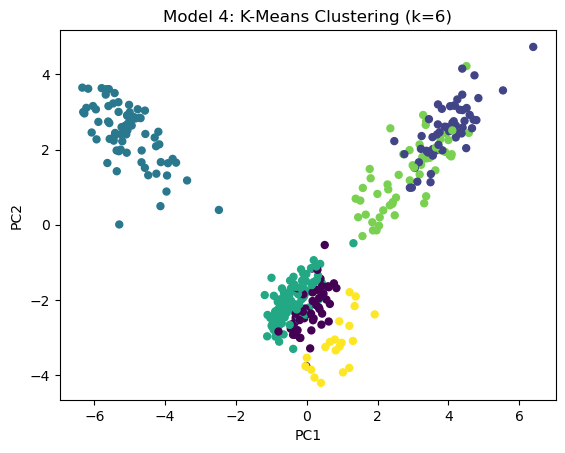

In [27]:
#K Means Visual
pca = PCA(n_components=2, random_state=42)
X2 = pca.fit_transform(X_scaled)

plt.figure()
plt.scatter(X2[:, 0], X2[:, 1], c=labels_km, s=25)
plt.title("Model 4: K-Means Clustering (k=" + str(K) + ")")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [28]:
#Model 5: Agglomerative Clustering
hc = AgglomerativeClustering(n_clusters=K, linkage="ward")
labels_hc = hc.fit_predict(X_scaled)

# Evaluate against true labels
sil_hc = silhouette_score(X_scaled, labels_hc)
ari_hc = adjusted_rand_score(y, labels_hc)

print("Hierarchical clustering silhouette:", sil_hc)
print("Hierarchical clustering ARI:", ari_hc)

Hierarchical clustering silhouette: 0.22824550564151747
Hierarchical clustering ARI: 0.9294929529386273


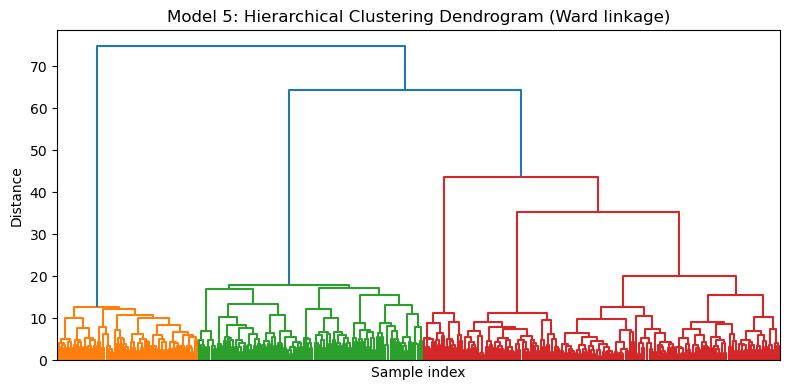

In [29]:
#Visual for Agg Cluster
Z = linkage(X_scaled, method="ward")
plt.figure(figsize=(8, 4))
plt.title("Model 5: Hierarchical Clustering Dendrogram (Ward linkage)")
plt.xlabel("Sample index")
plt.ylabel("Distance")
dendrogram(Z, no_labels=True, color_threshold=None)
plt.tight_layout()
plt.show()

In [30]:
#compare k means and agg cluster
print("K-Means  (Model 4) avg silhouette:", np.mean(scores), "avg ARI:", np.mean(ari_scores))
print("Hierarchical (Model 5) silhouette:", sil_hc, "ARI:", ari_hc)

K-Means  (Model 4) avg silhouette: 0.23582056464623086 avg ARI: 0.7107451555604535
Hierarchical (Model 5) silhouette: 0.22824550564151747 ARI: 0.9294929529386273


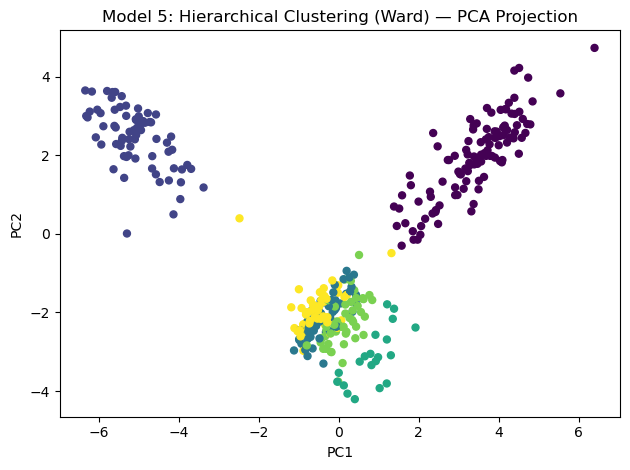

In [31]:
#Hierarchial clusters for visual
pca = PCA(n_components=2, random_state=42)
X2 = pca.fit_transform(X_scaled)

plt.figure()
plt.scatter(X2[:, 0], X2[:, 1], c=labels_hc, s=25)
plt.title("Model 5: Hierarchical Clustering (Ward) — PCA Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

### **PART 2**
#### INSTRUCTIONS

Use this data to answer the following questions. Use appropriate machine learning techniques/algorithms.

a. How does income inequality relate to the number of hate crimes and hate incidents? 

b. How can we predict the number of hate crimes and hate incidents from race/nature of the population? 

c. How does the number of hate crimes vary across states? Is there any similarity in number of hate incidents (per 100,000 people) between some states than in others — both according to the SPLC after the election and the FBI before it? 

Note: For the first two questions:

Choose the variables which you think are related to the predictors (income inequality, race and nature of the population) to build your model. Justify your selection.
Refine your model iteratively.
[Hint: You can use gradient descent, or/and add/remove variables in an incremental fashion].

d. For each of the decisions made about what techniques/algorithms to use, make sure to provide your justification or thoughts.

Shape: (51, 12)
Columns: ['state', 'median_household_income', 'share_unemployed_seasonal', 'share_population_in_metro_areas', 'share_population_with_high_school_degree', 'share_non_citizen', 'share_white_poverty', 'gini_index', 'share_non_white', 'share_voters_voted_trump', 'hate_crimes_per_100k_splc', 'avg_hatecrimes_per_100k_fbi']
Intercept: -14.689452682944667
Slope (Income inequality coefficient): 37.55424737386009
R²: 0.20894297693637365


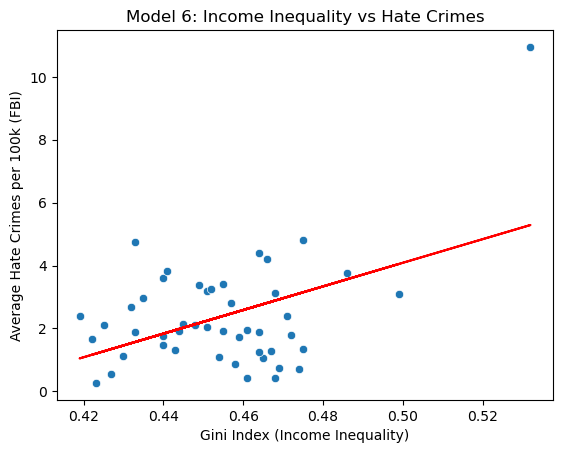

In [32]:
hc = pd.read_csv("hatecrime.csv")
print("Shape:", hc.shape)
print("Columns:", list(hc.columns))

# Select relevant columns (adjust names if slightly different)
cols = ['share_unemployed_seasonal', 'share_population_in_metro_areas', 
        'share_non_citizen', 'gini_index', 'avg_hatecrimes_per_100k_fbi']
hc_subset = hc[cols].dropna()

X = hc_subset[['gini_index']].values
y = hc_subset['avg_hatecrimes_per_100k_fbi'].values

# Fit simple linear regression (income inequality → hate crimes)
reg = LinearRegression()
reg.fit(X, y)
y_pred = reg.predict(X)

r2 = r2_score(y, y_pred)
print("Intercept:", reg.intercept_)
print("Slope (Income inequality coefficient):", reg.coef_[0])
print("R²:", r2)

# Visualize
plt.figure()
sns.scatterplot(x='gini_index', y='avg_hatecrimes_per_100k_fbi', data=hc_subset)
plt.plot(hc_subset['gini_index'], y_pred, color='red')
plt.title("Model 6: Income Inequality vs Hate Crimes")
plt.xlabel("Gini Index (Income Inequality)")
plt.ylabel("Average Hate Crimes per 100k (FBI)")
plt.show()

Available columns: ['state', 'median_household_income', 'share_unemployed_seasonal', 'share_population_in_metro_areas', 'share_population_with_high_school_degree', 'share_non_citizen', 'share_white_poverty', 'gini_index', 'share_non_white', 'share_voters_voted_trump', 'hate_crimes_per_100k_splc', 'avg_hatecrimes_per_100k_fbi']
Model 7 — Multiple Linear Regression
Predictors used: ['share_white_poverty', 'share_non_citizen', 'share_unemployed_seasonal', 'share_population_in_metro_areas']
RMSE: 2.9455495801372833
MAE: 1.7449244234046326
R²: -0.19052062828389982
                           Feature  Coefficient
0              share_white_poverty     0.208468
1                share_non_citizen     0.166241
2        share_unemployed_seasonal    -0.233952
3  share_population_in_metro_areas     0.044638


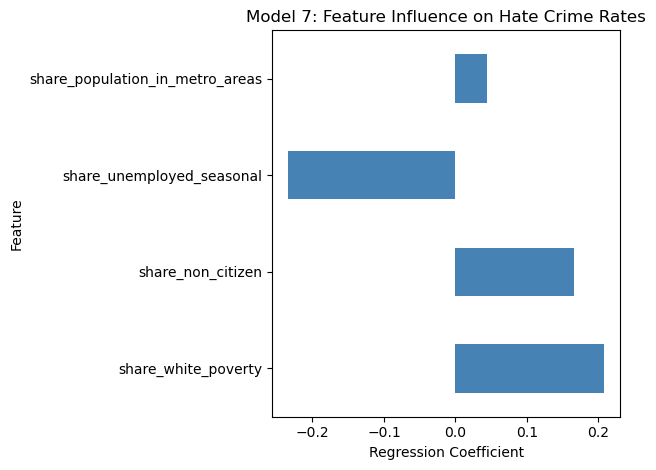

In [33]:
## Check what columns are available
print("Available columns:", list(hc.columns))

# Choose predictors only if they exist
candidate_predictors = [
    'share_white_poverty', 
    'share_non_citizen', 
    'share_unemployed_seasonal', 
    'share_population_in_metro_areas', 
    'share_black', 
    'share_asian', 
    'share_hispanic', 
    'share_white'
]

# Filter to columns that are actually present
predictors = [c for c in candidate_predictors if c in hc.columns]
target = 'avg_hatecrimes_per_100k_fbi'

hc_pred = hc[predictors + [target]].dropna()

X = hc_pred[predictors]
y = hc_pred[target]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Standardize + regression pipeline
model7 = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('reg', LinearRegression())
])

model7.fit(X_train, y_train)
y_pred = model7.predict(X_test)

# Evaluation
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model 7 — Multiple Linear Regression")
print("Predictors used:", predictors)
print("RMSE:", rmse)
print("MAE:", mae)
print("R²:", r2)

# Coefficients
coef_df = pd.DataFrame({'Feature': predictors, 'Coefficient': model7.named_steps['reg'].coef_})
print(coef_df)

# Visualize coefficients
import matplotlib.pyplot as plt
coef_df.set_index('Feature')['Coefficient'].plot(kind='barh', color='steelblue')
plt.title("Model 7: Feature Influence on Hate Crime Rates")
plt.xlabel("Regression Coefficient")
plt.tight_layout()
plt.show()

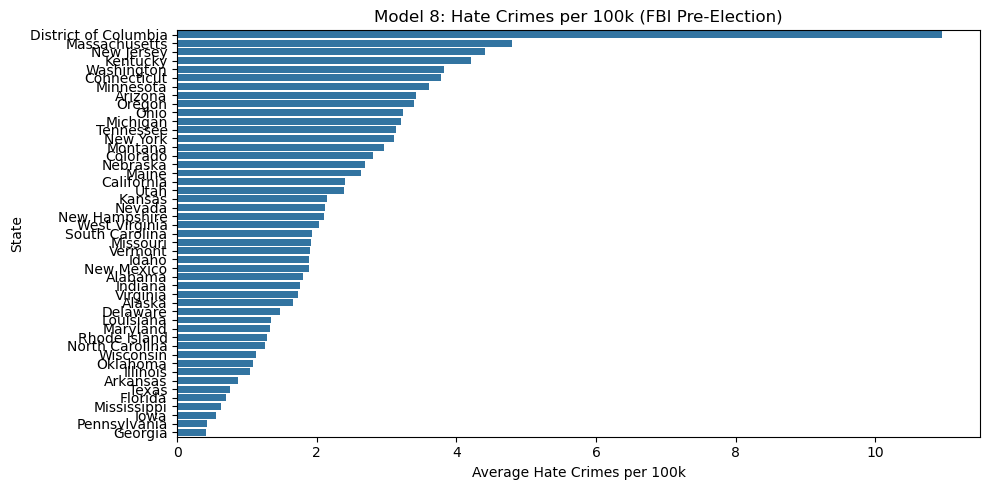

Correlation between SPLC and FBI rates: 0.7587004538248756


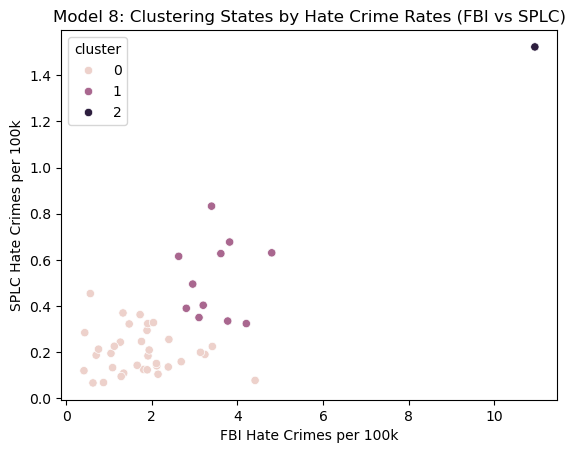

Cluster means:
          avg_hatecrimes_per_100k_fbi  hate_crimes_per_100k_splc
cluster                                                        
0                           1.737744                   0.202448
1                           3.481490                   0.516764
2                          10.953480                   1.522302


In [34]:
# Using SPLC (post-election) and FBI (pre-election) metrics if available
cols_state = ['state', 'avg_hatecrimes_per_100k_fbi', 'hate_crimes_per_100k_splc']
state_df = hc[cols_state].dropna()

# Visualization
plt.figure(figsize=(10, 5))
sns.barplot(x='avg_hatecrimes_per_100k_fbi', y='state', data=state_df.sort_values('avg_hatecrimes_per_100k_fbi', ascending=False))
plt.title("Model 8: Hate Crimes per 100k (FBI Pre-Election)")
plt.xlabel("Average Hate Crimes per 100k")
plt.ylabel("State")
plt.tight_layout()
plt.show()

# Compare SPLC vs FBI correlation
corr = state_df['avg_hatecrimes_per_100k_fbi'].corr(state_df['hate_crimes_per_100k_splc'])
print("Correlation between SPLC and FBI rates:", corr)

# Optional: cluster states based on both metrics
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

scaler = StandardScaler()
state_scaled = scaler.fit_transform(state_df[['avg_hatecrimes_per_100k_fbi', 'hate_crimes_per_100k_splc']])

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(state_scaled)
state_df['cluster'] = labels

plt.figure()
sns.scatterplot(x='avg_hatecrimes_per_100k_fbi', y='hate_crimes_per_100k_splc', hue='cluster', data=state_df)
plt.title("Model 8: Clustering States by Hate Crime Rates (FBI vs SPLC)")
plt.xlabel("FBI Hate Crimes per 100k")
plt.ylabel("SPLC Hate Crimes per 100k")
plt.show()

print("Cluster means:\n", state_df.groupby('cluster')[['avg_hatecrimes_per_100k_fbi', 'hate_crimes_per_100k_splc']].mean())